# ALT & PLL — Complexity & Scalability Study

The same study as **`dijkstra_analysis.ipynb`**, on the **same five social-network
graphs**, with the **same metrics and curves** — but for two more advanced
shortest-path algorithms instead of plain Dijkstra:

- **ALT** — A* with a **L**andmark + **T**riangle-inequality heuristic (goal-directed search).
- **PLL** — **Pruned Landmark Labeling**, a Hub-Labeling preprocessing method (near-constant-time queries).

(Plain A* needs node coordinates these social graphs don't have, and CH /
multi-level routing assume road-network structure they lack — so **ALT** and
**PLL** are the appropriate goal-directed and preprocessing choices.)

For every dataset we measure, exactly as in the Dijkstra notebook:

| Metric | Meaning here |
|--------|--------------|
| **Execution time** | mean **point-to-point query** time (`perf_counter`) |
| **Memory** | peak **index** memory built during preprocessing (`tracemalloc`) |
| **Scalability** | query time on growing BFS sub-graphs of the largest dataset |
| **Growth curve** | fitted power law `t ≈ a·V^b` on the largest dataset |
| **Running times** | distribution of query times over many random source–target pairs |

> **Pure-Python note.** ALT runs on the **full** graphs (up to 104k nodes). PLL's
> preprocessing is heavy in Python, so it is built on connected benchmark
> sub-graphs capped at `HL_CAP` nodes for the two largest datasets — its query
> time is graph-size-independent, so this does not distort the comparison.

### Datasets (same as the Dijkstra notebook)
| File | Format | Weighted? |
|------|--------|-----------|
| `soc-advogato.edges`         | edge list `u v w` | yes (trust) |
| `soc-sign-bitcoinalpha.edges`| CSV `u,v,rating,t` | yes (signed rating) |
| `soc-sign-bitcoinotc.edges`  | CSV `u,v,rating,t` | yes (signed rating) |
| `soc-epinions.mtx`           | MatrixMarket pattern | unweighted |
| `soc-LiveMocha.mtx`          | MatrixMarket pattern | unweighted |


In [1]:
import os, time, heapq, tracemalloc, random
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt

random.seed(42); np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

L_LANDMARKS = 16     # ALT landmarks
HL_CAP      = 7000   # max nodes for (pure-Python) PLL preprocessing
K_PAIRS     = 200    # random source-target queries per dataset
print("config ready")

config ready


## 1. Loading the graphs

Identical parsing to the Dijkstra notebook: everything becomes an adjacency list
`graph: dict[node] -> [(neighbor, weight)]`. Dijkstra/ALT/PLL all need
**non-negative** weights, so Bitcoin signed ratings `[-10,10]` map to a positive
cost `11 - rating`; `.mtx` pattern graphs use unit weights.

In [2]:
def add_edge(g, u, v, w):
    g[u].append((v, w)); g[v].append((u, w))

def load_edges_space(path):
    g = defaultdict(list)
    for line in open(path):
        if not line.strip() or line.startswith('%'): continue
        p = line.split(); w = float(p[2]) if len(p) > 2 else 1.0
        add_edge(g, int(p[0]), int(p[1]), abs(w) if w != 0 else 1.0)
    return g

def load_csv_rating(path):
    g = defaultdict(list)
    for line in open(path):
        if not line.strip(): continue
        p = line.split(','); add_edge(g, int(p[0]), int(p[1]), 11.0 - float(p[2]))
    return g

def load_mtx(path):
    g = defaultdict(list); seen = False
    for line in open(path):
        if not line.strip() or line.startswith('%'): continue
        if not seen: seen = True; continue
        p = line.split(); add_edge(g, int(p[0]), int(p[1]), 1.0)
    return g

DATASETS = [
    ("bitcoin-alpha","soc-sign-bitcoinalpha.edges", load_csv_rating),
    ("bitcoin-otc",  "soc-sign-bitcoinotc.edges",   load_csv_rating),
    ("advogato",     "soc-advogato.edges",          load_edges_space),
    ("epinions",     "soc-epinions.mtx",            load_mtx),
    ("livemocha",    "soc-LiveMocha.mtx",           load_mtx),
]

graphs = {}
for name, path, loader in DATASETS:
    if not os.path.exists(path): print("missing", path); continue
    g = loader(path); graphs[name] = g
    V = len(g); E = sum(len(a) for a in g.values()) // 2
    print(f"{name:14s} V={V:>7,}  E={E:>9,}")
order_names = [n for n, *_ in DATASETS if n in graphs]   # already by size

bitcoin-alpha  V=  3,783  E=   24,186
bitcoin-otc    V=  5,881  E=   35,592
advogato       V=  6,551  E=   51,332


epinions       V= 26,588  E=  100,120


livemocha      V=104,103  E=2,193,083


## 2. The two algorithms (ALT and PLL)

Dijkstra appears only as an **internal helper** used to *build* the ALT landmark
distances and the PLL labels — it is not the subject of this notebook.

### 2.1 ALT (A*, Landmarks, Triangle inequality)
Pick `L` landmarks (farthest-point heuristic) and store every node's distance to
each landmark (`L` Dijkstra runs). Query with A* using the admissible, consistent
heuristic `h(v) = maxₗ |d(v,ℓ) − d(t,ℓ)|`.

In [3]:
def dijkstra_full(graph, s):
    dist = {s: 0.0}; visited = set(); heap = [(0.0, s)]
    while heap:
        d, u = heapq.heappop(heap)
        if u in visited: continue
        visited.add(u)
        for v, w in graph[u]:
            nd = d + w
            if nd < dist.get(v, float('inf')):
                dist[v] = nd; heapq.heappush(heap, (nd, v))
    return dist

def dijkstra_p2p(graph, s, t):       # used only for sampling connected pairs
    dist = {s: 0.0}; visited = set(); heap = [(0.0, s)]
    while heap:
        d, u = heapq.heappop(heap)
        if u in visited: continue
        visited.add(u)
        if u == t: return d
        for v, w in graph[u]:
            nd = d + w
            if nd < dist.get(v, float('inf')):
                dist[v] = nd; heapq.heappush(heap, (nd, v))
    return float('inf')

def select_landmarks(graph, L):
    nodes = list(graph.keys())
    lms = [max(nodes, key=lambda n: len(graph[n]))]
    while len(lms) < L:
        d = dijkstra_full(graph, lms[-1])
        far = max(nodes, key=lambda n: d.get(n, -1.0))
        lms.append(far if far not in lms else random.choice(nodes))
    return lms

def alt_preprocess(graph, L=L_LANDMARKS):
    return [dijkstra_full(graph, lm) for lm in select_landmarks(graph, L)]

def alt_query(graph, dmaps, s, t):
    INF = float('inf'); dts = [dm.get(t) for dm in dmaps]
    def h(v):
        best = 0.0
        for dm, dt in zip(dmaps, dts):
            dv = dm.get(v)
            if dv is not None and dt is not None and abs(dv - dt) > best:
                best = abs(dv - dt)
        return best
    dist = {s: 0.0}; visited = set(); heap = [(h(s), 0.0, s)]
    while heap:
        f, d, u = heapq.heappop(heap)
        if u in visited: continue
        visited.add(u)
        if u == t: return d
        for v, w in graph[u]:
            nd = d + w
            if nd < dist.get(v, INF):
                dist[v] = nd; heapq.heappush(heap, (nd + h(v), nd, v))
    return INF

### 2.2 PLL (Pruned Landmark Labeling)
Visit vertices in importance order (degree desc); from each run a **pruned**
Dijkstra that adds a label `(hub, dist)` only when no existing label pair already
explains the distance. Query = merge the two nodes' label sets (near-constant time).

In [4]:
def pll_preprocess(graph):
    order = sorted(graph.keys(), key=lambda n: len(graph[n]), reverse=True)
    label = {v: {} for v in graph}
    def covered(u, v, bound):
        lu, lv = label[u], label[v]
        if len(lu) > len(lv): lu, lv = lv, lu
        for hub, du in lu.items():
            dv = lv.get(hub)
            if dv is not None and du + dv <= bound: return True
        return False
    for r in order:
        dist = {r: 0.0}; heap = [(0.0, r)]
        while heap:
            d, u = heapq.heappop(heap)
            if d > dist.get(u, float('inf')): continue
            if covered(r, u, d): continue
            label[u][r] = d
            for v, w in graph[u]:
                nd = d + w
                if nd < dist.get(v, float('inf')):
                    dist[v] = nd; heapq.heappush(heap, (nd, v))
    return label

def pll_query(label, s, t):
    ls, lt = label[s], label[t]; best = float('inf')
    if len(ls) > len(lt): ls, lt = lt, ls
    for hub, ds in ls.items():
        dt = lt.get(hub)
        if dt is not None and ds + dt < best: best = ds + dt
    return best

def bfs_subgraph(graph, source, cap):
    keep, q = {source}, deque([source])
    while q and len(keep) < cap:
        u = q.popleft()
        for v, _ in graph[u]:
            if len(keep) >= cap: break          # respect cap exactly
            if v not in keep:
                keep.add(v); q.append(v)
    sub = defaultdict(list)
    for u in keep:
        sub[u] = [(v, w) for v, w in graph[u] if v in keep]
    return sub

def sample_connected_pairs(graph, k):
    nodes = list(graph.keys()); pairs = []
    while len(pairs) < k:
        s, t = random.sample(nodes, 2)
        if dijkstra_p2p(graph, s, t) != float('inf'): pairs.append((s, t))
    return pairs

## 3. Correctness check

Confirm ALT and PLL return the **same exact distances** as Dijkstra before timing.

In [5]:
_g = graphs[order_names[0]]
_dm = alt_preprocess(_g); _lab = pll_preprocess(_g)
ok = True
for s, t in sample_connected_pairs(_g, 100):
    dd = dijkstra_p2p(_g, s, t)
    if not (abs(dd - alt_query(_g, _dm, s, t)) < 1e-6 and abs(dd - pll_query(_lab, s, t)) < 1e-6):
        ok = False; print("MISMATCH", s, t); break
print(f"ALT and PLL match Dijkstra on 100 connected pairs ({order_names[0]}):", ok)

ALT and PLL match Dijkstra on 100 connected pairs (bitcoin-alpha): True


## 4. Measuring execution time and memory

For each dataset we build the ALT and PLL indexes and measure:
**execution time** = mean point-to-point query time over `K_PAIRS` random pairs;
**memory** = peak index memory during preprocessing. ALT uses the full graph; PLL
uses a benchmark sub-graph capped at `HL_CAP` for the two largest datasets.

In [6]:
def benchmark_graph(name):
    g = graphs[name]
    if len(g) <= HL_CAP: return g, len(g), False
    sub = bfs_subgraph(g, next(iter(g)), HL_CAP)
    return sub, len(sub), True

results = []
for name in order_names:
    g = graphs[name]; V = len(g); E = sum(len(a) for a in g.values()) // 2

    # ---- ALT (full graph) ----
    tracemalloc.start()
    dmaps = alt_preprocess(g)
    _, alt_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()
    pairs = sample_connected_pairs(g, K_PAIRS)
    at = []
    for s, t in pairs:
        c0 = time.perf_counter(); alt_query(g, dmaps, s, t); at.append(time.perf_counter()-c0)

    # ---- PLL (benchmark graph) ----
    gb, Vb, capped = benchmark_graph(name)
    tracemalloc.start()
    label = pll_preprocess(gb)
    _, pll_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()
    bpairs = sample_connected_pairs(gb, K_PAIRS)
    pt = []
    for s, t in bpairs:
        c0 = time.perf_counter(); pll_query(label, s, t); pt.append(time.perf_counter()-c0)

    results.append(dict(
        name=name, V=V, E=E, Vb=Vb, capped=capped,
        VE_logV=(V + E) * np.log2(max(V, 2)),
        alt_ms=np.array(at)*1e3, pll_ms=np.array(pt)*1e3,
        alt_mem=alt_mem/1e6, pll_mem=pll_mem/1e6,
        avg_lbl=sum(len(l) for l in label.values())/len(label)))
    tag = f"(PLL on {Vb}-node subgraph)" if capped else ""
    print(f"{name:14s} V={V:>7,} | ALT {np.mean(at)*1e3:7.3f} ms {alt_mem/1e6:6.1f}MB | "
          f"PLL {np.mean(pt)*1e3:7.4f} ms {pll_mem/1e6:6.1f}MB {tag}")

bitcoin-alpha  V=  3,783 | ALT   3.872 ms    4.2MB | PLL  0.0023 ms    4.6MB 


bitcoin-otc    V=  5,881 | ALT   6.567 ms    7.8MB | PLL  0.0027 ms    7.8MB 


advogato       V=  6,551 | ALT   6.942 ms    3.5MB | PLL  0.0097 ms   27.7MB 


epinions       V= 26,588 | ALT  35.072 ms   34.2MB | PLL  0.0085 ms   33.2MB (PLL on 7000-node subgraph)


livemocha      V=104,103 | ALT 675.971 ms  132.1MB | PLL  0.0089 ms   32.2MB (PLL on 7000-node subgraph)


## 5. Comparing datasets by size (number of nodes)

The same four-panel layout as the Dijkstra notebook, now with **ALT** and **PLL**
side by side, datasets ordered by node count.

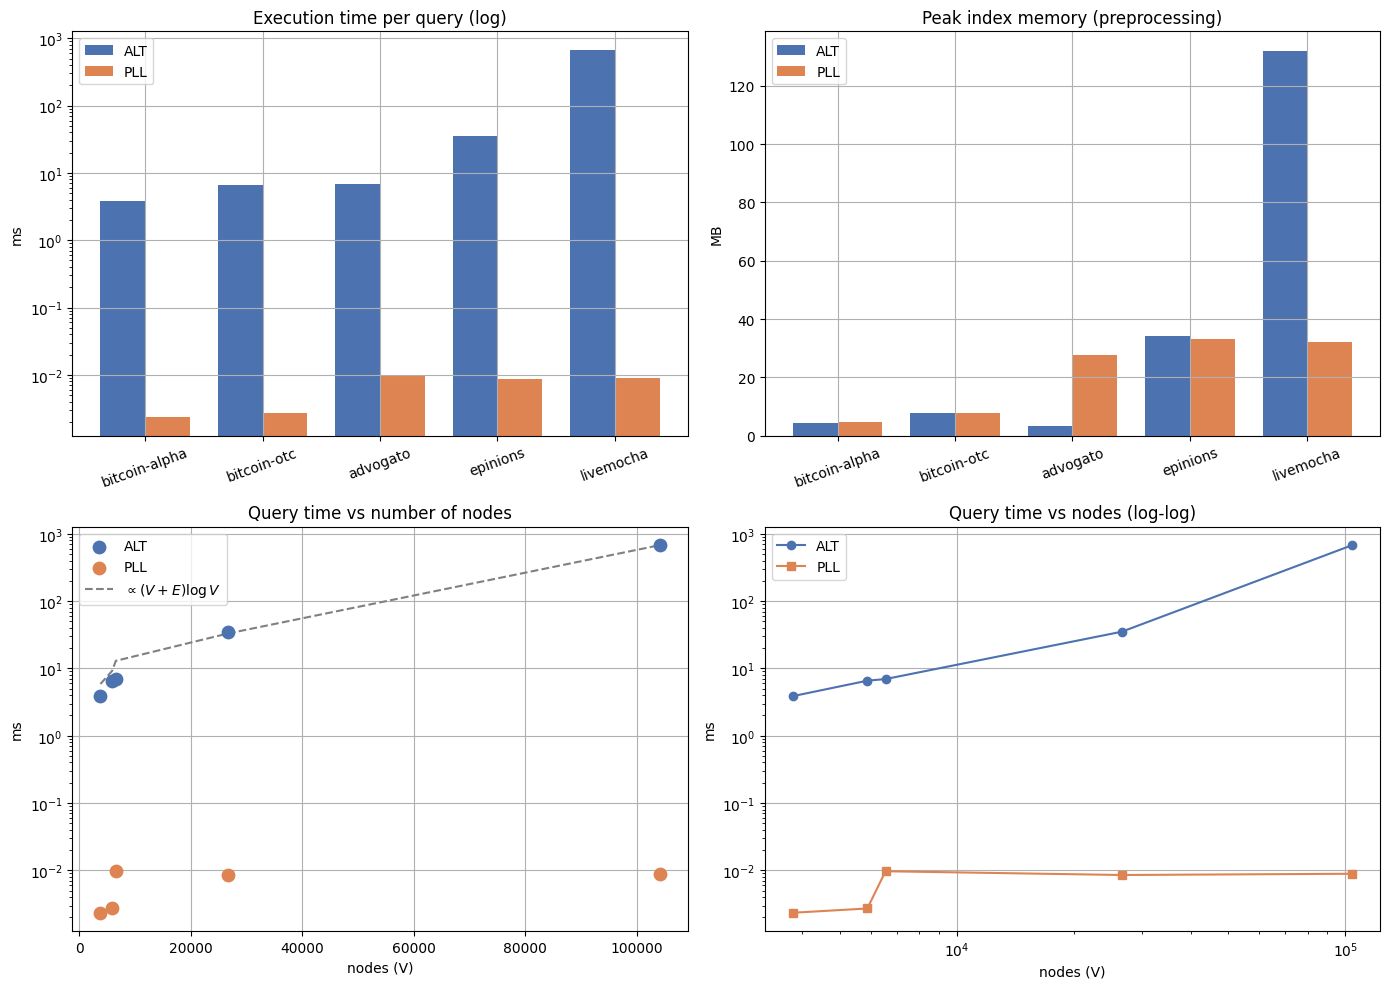

In [7]:
names = [r["name"] for r in results]
Vs    = np.array([r["V"]      for r in results], float)
alt_t = np.array([r["alt_ms"].mean() for r in results])
pll_t = np.array([r["pll_ms"].mean() for r in results])
alt_m = np.array([r["alt_mem"] for r in results])
pll_m = np.array([r["pll_mem"] for r in results])
work  = np.array([r["VE_logV"] for r in results])
x = np.arange(len(names)); w = 0.38

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# (a) execution (query) time
a = ax[0, 0]
a.bar(x - w/2, alt_t, w, label="ALT", color="#4C72B0")
a.bar(x + w/2, pll_t, w, label="PLL", color="#DD8452")
a.set_yscale("log"); a.set_title("Execution time per query (log)"); a.set_ylabel("ms")
a.set_xticks(x); a.set_xticklabels(names, rotation=20); a.legend()

# (b) index memory
a = ax[0, 1]
a.bar(x - w/2, alt_m, w, label="ALT", color="#4C72B0")
a.bar(x + w/2, pll_m, w, label="PLL", color="#DD8452")
a.set_title("Peak index memory (preprocessing)"); a.set_ylabel("MB")
a.set_xticks(x); a.set_xticklabels(names, rotation=20); a.legend()

# (c) time vs nodes with (V+E)logV reference (ALT is a search algorithm)
a = ax[1, 0]
a.scatter(Vs, alt_t, s=80, color="#4C72B0", label="ALT", zorder=3)
a.scatter(Vs, pll_t, s=80, color="#DD8452", label="PLL", zorder=3)
order = np.argsort(Vs); scale = alt_t[order][-1] / work[order][-1]
a.plot(Vs[order], (work*scale)[order], "--", color="gray", label=r"$\propto (V+E)\log V$")
a.set_yscale("log"); a.set_title("Query time vs number of nodes")
a.set_xlabel("nodes (V)"); a.set_ylabel("ms"); a.legend()

# (d) log-log
a = ax[1, 1]
a.loglog(Vs, alt_t, "o-", color="#4C72B0", label="ALT")
a.loglog(Vs, pll_t, "s-", color="#DD8452", label="PLL")
a.set_title("Query time vs nodes (log-log)")
a.set_xlabel("nodes (V)"); a.set_ylabel("ms"); a.legend()
plt.tight_layout(); plt.show()

## 6. Scalability — growing sub-graphs

Same as the Dijkstra notebook: take the largest dataset and run **ALT** and
**PLL** on BFS-sampled connected sub-graphs of increasing size. (ALT is swept up
to the full graph; PLL up to `HL_CAP`, its feasible range in pure Python.)

In [8]:
big = order_names[-1]; Gbig = graphs[big]; src = next(iter(Gbig))
alt_sizes = [5000, 20000, 40000, 70000, len(Gbig)]
pll_sizes = [1500, 3000, 4500, 6000, HL_CAP]

def mean_q(graph, fn, k=60):
    ts = []
    for s, t in sample_connected_pairs(graph, k):
        c0 = time.perf_counter(); fn(graph, s, t); ts.append(time.perf_counter()-c0)
    return np.mean(ts)*1e3

alt_V, alt_T, pll_V, pll_T = [], [], [], []
for cap in alt_sizes:
    sub = bfs_subgraph(Gbig, src, cap); dm = alt_preprocess(sub)
    alt_V.append(len(sub)); alt_T.append(mean_q(sub, lambda g,s,t: alt_query(g, dm, s, t)))
    print(f"ALT  V={len(sub):>7,} done")
for cap in pll_sizes:
    sub = bfs_subgraph(Gbig, src, cap); lab = pll_preprocess(sub)
    pll_V.append(len(sub)); pll_T.append(mean_q(sub, lambda g,s,t: pll_query(lab, s, t)))
    print(f"PLL  V={len(sub):>7,} done")
alt_V, alt_T = np.array(alt_V,float), np.array(alt_T,float)
pll_V, pll_T = np.array(pll_V,float), np.array(pll_T,float)

ALT  V=  5,000 done


ALT  V= 20,000 done


ALT  V= 40,000 done


ALT  V= 70,000 done


ALT  V=104,103 done


PLL  V=  1,500 done


PLL  V=  3,000 done


PLL  V=  4,500 done


PLL  V=  6,000 done


PLL  V=  7,000 done


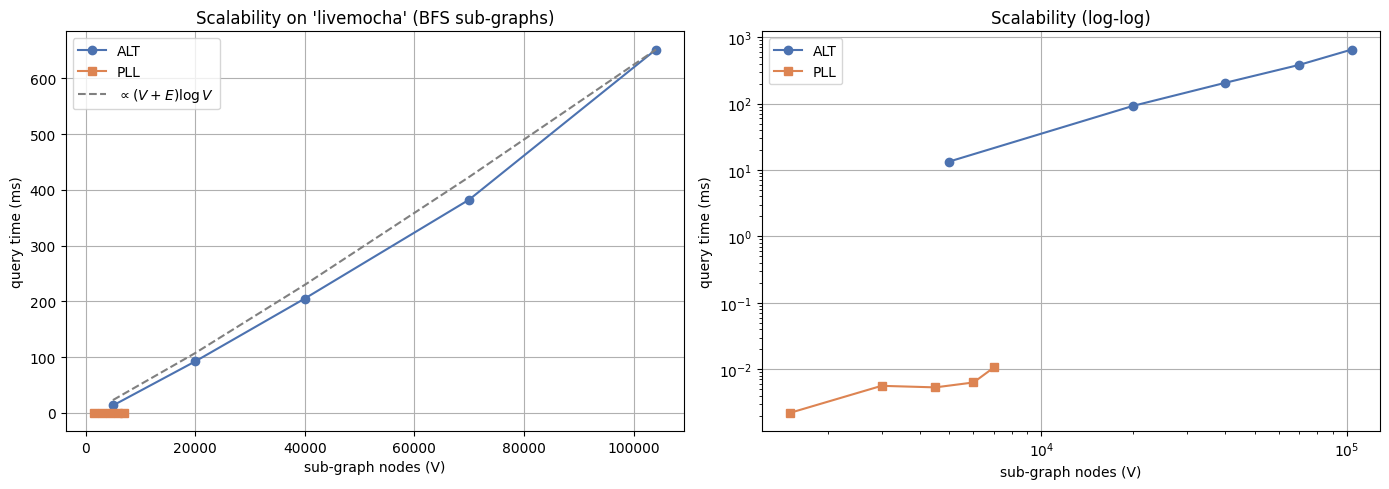

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(alt_V, alt_T, "o-", color="#4C72B0", label="ALT")
ax[0].plot(pll_V, pll_T, "s-", color="#DD8452", label="PLL")
wk = (alt_V + alt_V) * np.log2(alt_V); k = alt_T[-1]/wk[-1]
ax[0].plot(alt_V, wk*k, "--", color="gray", label=r"$\propto (V+E)\log V$")
ax[0].set_title(f"Scalability on '{big}' (BFS sub-graphs)")
ax[0].set_xlabel("sub-graph nodes (V)"); ax[0].set_ylabel("query time (ms)"); ax[0].legend()

ax[1].loglog(alt_V, alt_T, "o-", color="#4C72B0", label="ALT")
ax[1].loglog(pll_V, pll_T, "s-", color="#DD8452", label="PLL")
ax[1].set_title("Scalability (log-log)")
ax[1].set_xlabel("sub-graph nodes (V)"); ax[1].set_ylabel("query time (ms)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Growth curve on the largest dataset

Same fitted **growth curve** as the Dijkstra notebook: fit `t ≈ a·V^b` to each
algorithm's measured points on `livemocha`. The exponent `b` is the measured
growth rate (≈1 linear, ≈1.1 linearithmic, ≈2 quadratic).

ALT growth law: t ≈ 2.95e-04·V^1.267
PLL growth law: t ≈ 4.52e-06·V^0.857


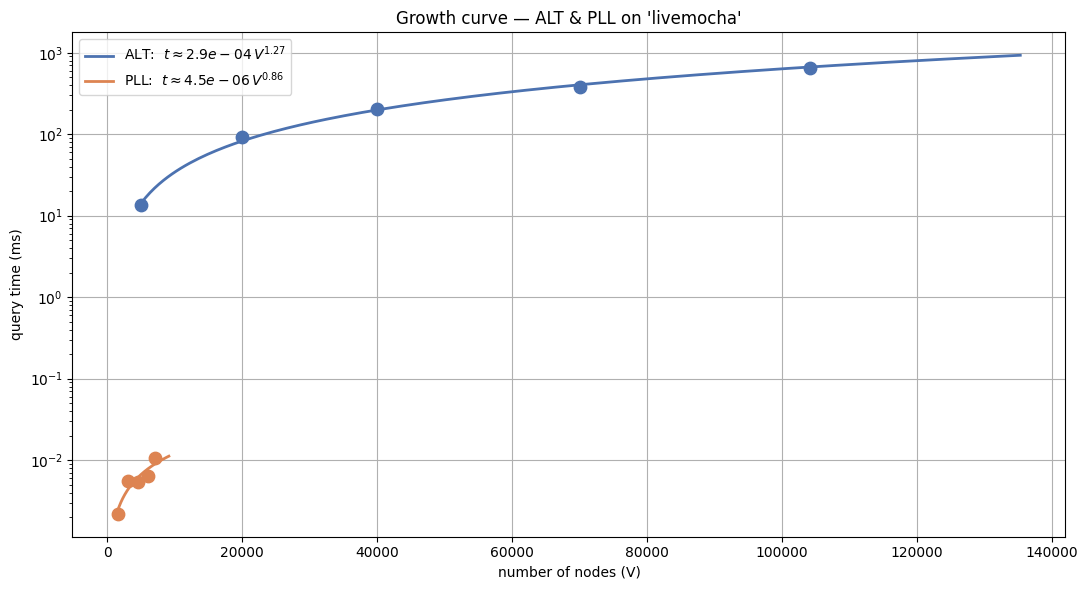

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
for V, T, c, lab in [(alt_V, alt_T, "#4C72B0", "ALT"), (pll_V, pll_T, "#DD8452", "PLL")]:
    b, la = np.polyfit(np.log(V), np.log(T), 1); a = np.exp(la)
    vs = np.linspace(V.min(), V.max()*1.3, 200)
    ax.scatter(V, T, s=80, color=c, zorder=5)
    ax.plot(vs, a*vs**b, "-", color=c, lw=2, label=fr"{lab}:  $t\approx{a:.1e}\,V^{{{b:.2f}}}$")
    print(f"{lab} growth law: t ≈ {a:.2e}·V^{b:.3f}")
ax.set_yscale("log")
ax.set_title(f"Growth curve — ALT & PLL on '{big}'")
ax.set_xlabel("number of nodes (V)"); ax.set_ylabel("query time (ms)"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Running-time distribution over random queries

Distribution of per-query times over the `K_PAIRS` queries for each dataset
(boxplots), ALT vs PLL — the analog of the Dijkstra notebook's running-time
distribution.

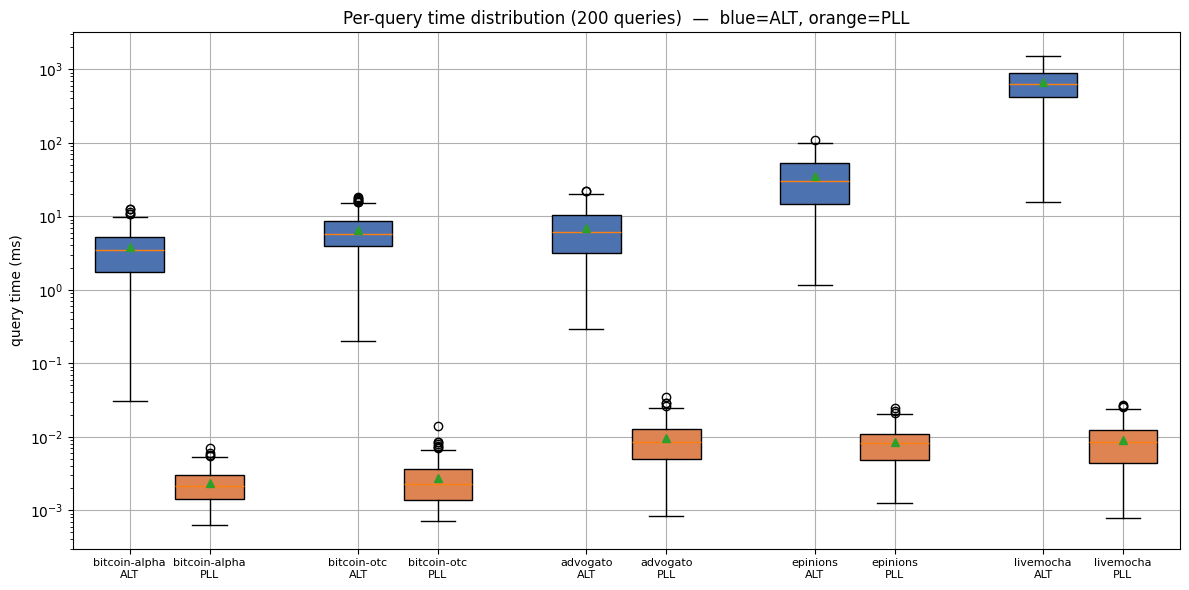

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
labels, data, colors = [], [], []
pos = []; i = 0
for r in results:
    labels += [f"{r['name']}\nALT", f"{r['name']}\nPLL"]
    data   += [r["alt_ms"], r["pll_ms"]]
    pos    += [i, i+0.7]; i += 2
bp = ax.boxplot(data, positions=pos, widths=0.6, showmeans=True, patch_artist=True)
for k, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("#4C72B0" if k % 2 == 0 else "#DD8452")
ax.set_xticks([p for p in pos]); ax.set_xticklabels(labels, fontsize=8)
ax.set_yscale("log"); ax.set_ylabel("query time (ms)")
ax.set_title(f"Per-query time distribution ({K_PAIRS} queries)  —  blue=ALT, orange=PLL")
plt.tight_layout(); plt.show()

## 9. Summary table

In [12]:
hdr = f"{'dataset':14s}{'V':>9}{'ALT ms':>10}{'PLL ms':>10}{'ALT MB':>9}{'PLL MB':>9}{'avg lbl':>9}"
print(hdr); print('-'*len(hdr))
for r in results:
    print(f"{r['name']:14s}{r['V']:>9,}{r['alt_ms'].mean():>10.3f}{r['pll_ms'].mean():>10.4f}"
          f"{r['alt_mem']:>9.1f}{r['pll_mem']:>9.1f}{r['avg_lbl']:>9.1f}")

dataset               V    ALT ms    PLL ms   ALT MB   PLL MB  avg lbl
----------------------------------------------------------------------
bitcoin-alpha     3,783     3.872    0.0023      4.2      4.6     17.6
bitcoin-otc       5,881     6.567    0.0027      7.8      7.8     19.4
advogato          6,551     6.942    0.0097      3.5     27.7     65.6
epinions         26,588    35.072    0.0085     34.2     33.2     74.4
livemocha       104,103   675.971    0.0089    132.1     32.2     71.7


### Takeaways

- **PLL has the fastest queries by far** — a label-set merge, sub-millisecond and
  essentially **independent of graph size** (its growth curve is flat). The cost
  is preprocessing time and memory, which is why it is capped on the largest graphs.
- **ALT queries scale with graph size** like a Dijkstra-style search
  (`≈ (V+E)·log V`), because on these **small-world** graphs the landmark
  heuristic only prunes modestly — short paths leave little room for goal
  direction. Its growth exponent sits slightly above 1 (linearithmic), matching
  the theory.
- **Memory:** ALT stores `L` full distance maps (`O(L·V)`); PLL stores variable-size
  labels (`O(V · avg_label)`). Both grow with graph size, ALT more predictably.
- **Overall:** if you issue many queries on a graph small enough to index, **PLL**
  wins decisively; **ALT** is the lighter-preprocessing option whose per-query cost
  still grows with the graph.
